In [2]:
#-----------Task 2------------

#Load historical stock data
import yfinance as yf
import pandas as pd
df = yf.download("AAPL", start="2023-01-01", end="2025-01-01")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096008  128.833987  122.210212  128.223777  112117500
2023-01-04  124.365662  126.629364  123.105865  124.887295   89113600
2023-01-05  123.046829  125.753426  122.790938  125.123528   80962700
2023-01-06  127.574181  128.233604  122.918839  124.021165   87754700
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800


In [ ]:
# Understand the data
print(df.shape)

(502, 5)


In [5]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [ ]:
# Create target column
print(df.info)
df["Target"] = df["Close"].shift(-1)

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2023-01-03  123.096008  128.833987  122.210212  128.223777  112117500   
2023-01-04  124.365662  126.629364  123.105865  124.887295   89113600   
2023-01-05  123.046829  125.753426  122.790938  125.123528   80962700   
2023-01-06  127.574181  128.233604  122.918839  124.021165   87754700   
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800   
...                ...         ...         ...         ...        ...   
2024-12-24  256.797180  256.807105  253.902972  254.101897   23234700   
2024-12-26  257.612701  258.686851  256.230269  256.787224   27237100   
2024-12-27  254.201370  257.294489  251.685117  256.429191   42355300   
2024-12-30  250.829803  252.122744  249.387684  250.859639   35557500   
2024-12-31  249.059

In [8]:
df["Target"] = df["Close"].shift(-1)

In [ ]:
# Remove missing last row
df = df.dropna()

In [11]:
print(df.info)

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2023-01-03  123.096008  128.833987  122.210212  128.223777  112117500   
2023-01-04  124.365662  126.629364  123.105865  124.887295   89113600   
2023-01-05  123.046829  125.753426  122.790938  125.123528   80962700   
2023-01-06  127.574181  128.233604  122.918839  124.021165   87754700   
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800   
...                ...         ...         ...         ...        ...   
2024-12-23  253.883118  254.261043  252.072998  253.385834   40858800   
2024-12-24  256.797180  256.807105  253.902972  254.101897   23234700   
2024-12-26  257.612701  258.686851  256.230269  256.787224   27237100   
2024-12-27  254.201370  257.294489  251.685117  256.429191   42355300   
2024-12-30  250.829

In [12]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Target"]

In [ ]:
# Train/test split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Predict
predictions = model.predict(X_test)


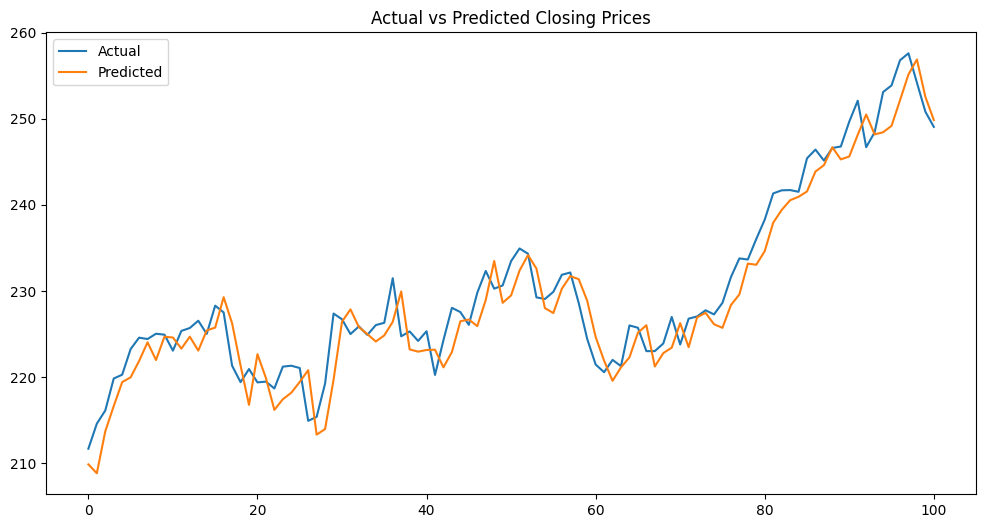

In [ ]:
# Compare actual vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()